# Kapitel 6 – Klustring

Individuella övningsuppgifter.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

## Fråga 1

### Vad är klustring för något? Ge några exempel på tillämpningsområden.

Klustring är en typ av **unsupervised learning** där modellen försöker hitta grupper i data utan att det finns en färdig target `y`.

Observationer som liknar varandra hamnar i samma kluster.

Exempel på användning:

- kundsegmentering
- gruppering av bostadsområden
- gruppering av låtar efter egenskaper
- identifiera liknande beteenden eller mönster i data

## Fråga 2

### Förklara översiktligt hur K-means fungerar. Använd figur 6.3 och 6.4 i din förklaring.

K-means delar upp datan i ett bestämt antal kluster, `k`.

Väldigt förenklat fungerar det så här:

1. modellen placerar ut `k` centrum, så kallade centroids
2. varje observation kopplas till det närmaste centrumet
3. centrumet flyttas till mitten av observationerna i sitt kluster
4. processen upprepas tills klustren inte förändras särskilt mycket längre

Figur 6.3 visar exempel på riktiga kluster med olika former, storlekar och spridning.

Figur 6.4 visar att K-means inte alltid lyckas bra. Modellen fungerar bäst när klustren ungefär är runda och har liknande storlek och spridning.

![Figur 6.3](./img_6/figure_6_3.png)

![Figur 6.4](./img_6/figure_6_4.png)

## Fråga 3

### Hur kan man välja vilket antal kluster som ska användas för en K-means-modell? Använd inertia, silhouette score och silhouette diagram i ditt svar.

Det finns inget enda värde som alltid är rätt, men några vanliga sätt är:

**Inertia** mäter hur långt observationerna ligger från centrumet i sina kluster. Lägre är bättre, men inertia sjunker nästan alltid när fler kluster läggs till. Därför tittar man ofta efter en "armbåge" där förbättringen börjar plana ut.

**Silhouette score** mäter hur bra observationerna passar i sitt eget kluster jämfört med andra kluster. Värdet ligger mellan -1 och 1 och högre är generellt bättre.

**Silhouette diagram** visar silhouette-värden för varje observation och kluster. Det gör det lättare att se om klustren är tydliga och ungefär rimligt balanserade.

I praktiken använder man ofta flera av dessa metoder tillsammans och väger även in vad klustren ska användas till.

## Fråga 4

### Om du kollar på figur 6.10 på sidan 247, hur många kluster hade du valt och varför? Är det en exakt vetenskap att välja antalet kluster?

I figur 6.10 syns en tydlig böj ungefär vid **4 kluster**.

Efter `k = 4` fortsätter inertia att minska, men förbättringen blir betydligt mindre. Därför hade jag valt 4 som ett rimligt första val.

Det är däremot inte en exakt vetenskap. Elbow-metoden ger ett stöd för beslutet men gränsen kan vara ganska subjektiv.

Man kan därför även jämföra silhouette score och silhouette diagram och fundera på om klustren är meningsfulla för problemet.

![Figur 6.10](./img_6/figure_6_10.png)

## Fråga 5

### Hur tolkar man figur 6.13 på sidan 251?

Figuren jämför silhouette diagram för `k = 3`, `4`, `5` och `6`.

Den röda streckade linjen visar den genomsnittliga silhouette score för respektive modell.

Ett bra resultat innebär att många observationer har höga positiva silhouette-värden och att klustren inte innehåller mycket negativa värden.

I figuren verkar `k = 4` ge ett bra resultat. `k = 5` ligger också relativt bra till, medan fler kluster inte automatiskt ger bättre separation.

Poängen är att silhouette diagram hjälper oss bedöma både hur tydliga klustren är och om ett visst antal kluster verkar rimligt.

![Figur 6.13](./img_6/figure_6_13.png)

## Fråga 7

### I koden nedan används `housing.csv` och K-means.

#### a) Förklara vad koden gör.

Koden läser in bostadsdatan och väljer tre variabler:

- `median_income`
- `latitude`
- `longitude`

Sedan skapas en K-means-modell med 6 kluster.

`fit_predict()` tränar modellen och ger varje observation ett klusternummer mellan 0 och 5.

Till sist visualiseras klustren geografiskt genom longitude och latitude.

In [2]:
housing_path = Path("chapter_06_clustering/data/housing.csv")
if not housing_path.exists():
    housing_path = Path("data/housing.csv")

housing = pd.read_csv(housing_path)

X_housing = housing[["median_income", "latitude", "longitude"]].copy()

kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
X_housing["Cluster"] = kmeans.fit_predict(X_housing)

X_housing.head()

,median_income,latitude,longitude,Cluster
0,8.3252,37.88,-122.23,5
1,8.3014,37.86,-122.22,5
2,7.2574,37.85,-122.24,5
3,5.6431,37.85,-122.25,5
4,3.8462,37.85,-122.25,0


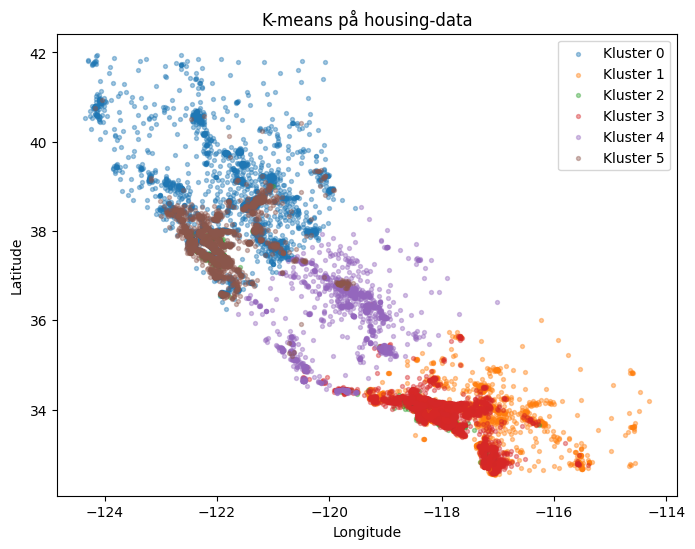

In [3]:
plt.figure(figsize=(8, 6))

for cluster in sorted(X_housing["Cluster"].unique()):
    cluster_data = X_housing[X_housing["Cluster"] == cluster]
    plt.scatter(
        cluster_data["longitude"],
        cluster_data["latitude"],
        s=8,
        alpha=0.4,
        label=f"Kluster {cluster}"
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("K-means på housing-data")
plt.legend()
plt.show()

#### b) Vilken information hade du velat ha om respektive kluster och hur hade du designat marknadsundersökningen?

Jag hade velat veta mer om:

- vilken typ av bostad personerna föredrar
- budget och inkomst
- om de vill köpa eller hyra
- hur de helst vill bli kontaktade
- hur viktigt läge, pendling och service är
- familjesituation och ungefärlig livssituation

Jag hade gjort en kort enkät där samma frågor ställs till personer i alla kluster.

Sedan hade jag jämfört svaren mellan grupperna för att se om klustren faktiskt har olika behov och preferenser.

#### c) Hur kan detta vara användbart för ett företag?

Ett företag skulle kunna använda klustren för att göra olika kundsegment.

Om grupperna visar sig ha olika behov kan marknadsföring, erbjudanden och kommunikation anpassas efter respektive segment.

Det kan exempelvis hjälpa ett bostadsföretag att rikta olika bostäder eller kampanjer till olika typer av kunder.

#### d) Undersök hur många kluster som kan vara rimligt.

Jag jämför några olika värden på `k` med silhouette score.

Eftersom K-means påverkas av skalan standardiserar jag först de tre variablerna.

In [4]:
housing_features = housing[["median_income", "latitude", "longitude"]]

scaler = StandardScaler()
housing_scaled = scaler.fit_transform(housing_features)

housing_scores = {}

for k in range(2, 9):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(housing_scaled)
    score = silhouette_score(housing_scaled, labels)
    housing_scores[k] = score

pd.Series(housing_scores, name="Silhouette score")

2    0.548225
3    0.517727
4    0.435079
5    0.386963
6    0.398465
7    0.370474
8    0.352519
Name: Silhouette score, dtype: float64

In [5]:
best_k_housing = max(housing_scores, key=housing_scores.get)

print("Bäst silhouette score fås med k =", best_k_housing)
print("Score:", round(housing_scores[best_k_housing], 3))

Bäst silhouette score fås med k = 2
Score: 0.548


Silhouette score ger ett förslag på vilket `k` som separerar grupperna bäst.

Det betyder inte automatiskt att detta är det enda rätta antalet kluster. I verkligheten hade jag också tittat på om segmenten faktiskt är användbara och går att tolka.

## Fråga 9

### Genomför en klusteranalys på datasetet "1980s classic hits with Spotify data".

Jag använder låtarnas numeriska ljudegenskaper och försöker hitta grupper av låtar som liknar varandra.

Jag använder inte `Track` eller `Artist` i själva K-means-modellen eftersom de är namn och inte numeriska ljudegenskaper.

In [6]:
spotify_path = Path("chapter_06_clustering/data/1980sClassics.csv")
if not spotify_path.exists():
    spotify_path = Path("data/1980sClassics.csv")

spotify = pd.read_csv(spotify_path)

spotify.head()

,Track,Artist,Duration,Time_Signature,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Popularity,Year
0,Babe,Styx,3:38,4,0.700,0.582,11,-5.960,0,0.0356,0.05020,0.000000,0.0881,0.785,116.712,96,1980
1,The Rose,Bette Midler,4:04,4,0.264,0.640,8,-6.221,1,0.0442,0.03930,0.000002,0.1510,0.190,84.828,92,1980
2,Cars,Gary Numan,4:08,4,0.338,0.562,9,-7.181,1,0.0290,0.03900,0.000000,0.1070,0.259,149.907,82,1980
3,Magic,Olivia Newton-John,2:17,4,0.911,0.689,1,-6.176,1,0.2650,0.00119,0.000000,0.0704,0.546,140.034,80,1980
4,We Don’t Talk Anymore,Cliff Richard,3:37,4,0.728,0.563,1,-8.053,0,0.1340,0.62100,0.000000,0.1790,0.352,100.017,80,1980


In [7]:
print("Antal låtar:", len(spotify))
print("Antal kolumner:", spotify.shape[1])
print("Saknade värden:", int(spotify.isna().sum().sum()))
print()
print(spotify.dtypes)

Antal låtar: 998
Antal kolumner: 17
Saknade värden: 0

Track                object
Artist               object
Duration             object
Time_Signature        int64
Danceability        float64
Energy              float64
Key                   int64
Loudness            float64
Mode                  int64
Speechiness         float64
Acousticness        float64
Instrumentalness    float64
Liveness            float64
Valence             float64
Tempo               float64
Popularity            int64
Year                  int64
dtype: object


Jag väljer ett mindre antal tydliga Spotify-features för att hålla analysen enkel:

- Danceability
- Energy
- Loudness
- Speechiness
- Acousticness
- Instrumentalness
- Liveness
- Valence
- Tempo

In [8]:
spotify_features = [
    "Danceability",
    "Energy",
    "Loudness",
    "Speechiness",
    "Acousticness",
    "Instrumentalness",
    "Liveness",
    "Valence",
    "Tempo"
]

X_spotify = spotify[spotify_features].copy()

scaler = StandardScaler()
X_spotify_scaled = scaler.fit_transform(X_spotify)

### Välj antal kluster

Jag testar `k = 2` till `8` och jämför silhouette score.

In [9]:
spotify_scores = {}
spotify_inertia = {}

for k in range(2, 9):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_spotify_scaled)

    spotify_scores[k] = silhouette_score(X_spotify_scaled, labels)
    spotify_inertia[k] = model.inertia_

results = pd.DataFrame({
    "Silhouette score": spotify_scores,
    "Inertia": spotify_inertia
})

results

,Silhouette score,Inertia
2,0.233737,7243.908200
3,0.167300,6466.049893
4,0.183917,5757.426396
5,0.187899,5274.798261
6,0.209088,4737.118149
7,0.171770,4372.894076
8,0.173925,4080.628164


In [10]:
best_k = max(spotify_scores, key=spotify_scores.get)

print("Bäst silhouette score:", best_k)
print("Score:", round(spotify_scores[best_k], 3))

Bäst silhouette score: 2
Score: 0.234


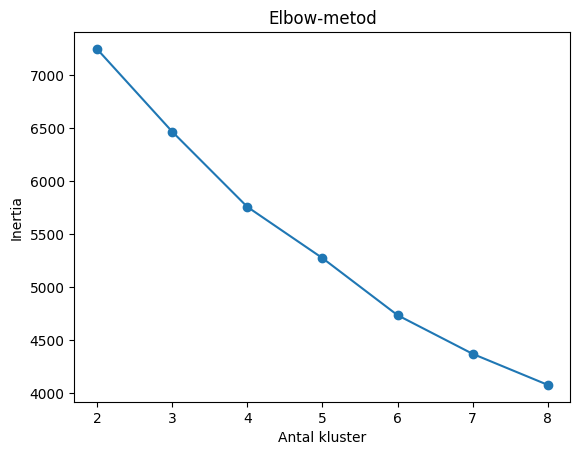

In [11]:
plt.plot(
    list(spotify_inertia.keys()),
    list(spotify_inertia.values()),
    marker="o"
)

plt.xlabel("Antal kluster")
plt.ylabel("Inertia")
plt.title("Elbow-metod")
plt.show()

### Träna slutlig K-means-modell

In [12]:
spotify_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

spotify["Cluster"] = spotify_kmeans.fit_predict(X_spotify_scaled)

spotify[["Track", "Artist", "Cluster"]].head(10)

,Track,Artist,Cluster
0,Babe,Styx,1
1,The Rose,Bette Midler,0
2,Cars,Gary Numan,0
3,Magic,Olivia Newton-John,1
4,We Don’t Talk Anymore,Cliff Richard,0
5,Desire,Andy Gibb,1
6,Real Love,Doobie Brothers,1
7,Rock With You,Michael Jackson,1
8,Sara,Fleetwood Mac,1
9,Upside Down,Diana Ross,1


### Undersök klustren

För att tolka klustren jämför jag medelvärdet av låtarnas egenskaper i varje grupp.

In [13]:
cluster_profile = (
    spotify.groupby("Cluster")[spotify_features]
    .mean()
    .round(2)
)

cluster_profile

,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo
Cluster,,,,,,,,,
0,0.53,0.42,-11.55,0.04,0.49,0.07,0.16,0.37,118.49
1,0.67,0.73,-7.73,0.06,0.14,0.03,0.19,0.71,121.96


In [14]:
cluster_sizes = spotify["Cluster"].value_counts().sort_index()
cluster_sizes

Cluster
0    303
1    695
Name: count, dtype: int64

### Exempel på låtar i varje kluster

In [15]:
for cluster in sorted(spotify["Cluster"].unique()):
    print(f"\nKluster {cluster}")
    display(
        spotify.loc[
            spotify["Cluster"] == cluster,
            ["Track", "Artist", "Danceability", "Energy", "Valence"]
        ].head(5)
    )


Kluster 0


,Track,Artist,Danceability,Energy,Valence
1,The Rose,Bette Midler,0.264,0.640,0.190
2,Cars,Gary Numan,0.338,0.562,0.259
4,We Don’t Talk Anymore,Cliff Richard,0.728,0.563,0.352
12,Lady,Kenny Rogers,0.539,0.160,0.322
18,Please Don’t Go,KC and the Sunshine Band,0.683,0.554,0.452



Kluster 1


,Track,Artist,Danceability,Energy,Valence
0,Babe,Styx,0.700,0.582,0.785
3,Magic,Olivia Newton-John,0.911,0.689,0.546
5,Desire,Andy Gibb,0.587,0.924,0.509
6,Real Love,Doobie Brothers,0.417,0.686,0.625
7,Rock With You,Michael Jackson,0.808,0.535,0.848


### Slutsats

K-means lyckades dela upp låtarna i grupper utifrån deras Spotify-egenskaper.

Genom att jämföra medelvärdena kan man se om vissa kluster exempelvis består av mer energiska, dansvänliga, akustiska eller positiva låtar.

Den här typen av klustring skulle exempelvis kunna användas för att skapa spellistor eller gruppera musik utan att någon i förväg behöver ange vilken genre varje låt tillhör.

Det finns inte ett exakt rätt antal kluster. Silhouette score och inertia ger stöd för valet, men hur användbara klustren är behöver också bedömas utifrån vad analysen ska användas till.